In [1]:
import pandas as pd
import numpy as np

print("1. Cargando el dataset masivo... (Ten paciencia, puede tardar 1-2 minutos)")
df = pd.read_csv('../data/Conexiones_WiFi_Campus.csv', low_memory=False)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M')

print("2. Aplastando los datos (Agrupando en bloques de 15 minutos)...")
# Aquí creamos la "X" (Lo que ve el router) y la "y" (El aforo real que queremos predecir)
df_ml = df.groupby('Timestamp').agg(
    Conexiones_WiFi=('MAC_Dispositivo', 'nunique'), # Lo que ve el sistema IT
    Aforo_Real=('ID_Universidad', lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique()) # La cruda realidad
).reset_index()

print("3. Creando las variables predictoras (Features)...")
# Extraemos el contexto temporal para que la IA entienda el mundo real
df_ml['Hora'] = df_ml['Timestamp'].dt.hour
df_ml['Minuto'] = df_ml['Timestamp'].dt.minute
df_ml['Dia_Semana'] = df_ml['Timestamp'].dt.dayofweek
df_ml['Es_FinDeSemana'] = np.where(df_ml['Dia_Semana'] >= 5, 1, 0)

# ---------------------------------------------------------
# IMPORTANTE: Aquí deberías cruzar (merge) tu df_ml con tus datos de CLIMA
# asumiendo que tienes un df_clima cargado previamente. Si no lo tienes a mano, 
# podemos entrenar el modelo base primero solo con el tiempo y el calendario.
# ---------------------------------------------------------

print(f"¡Datos listos para la IA! Tenemos {len(df_ml)} intervalos de 15 minutos.")
df_ml.head()

c:\Users\jordi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


1. Cargando el dataset masivo... (Ten paciencia, puede tardar 1-2 minutos)
2. Aplastando los datos (Agrupando en bloques de 15 minutos)...
3. Creando las variables predictoras (Features)...
¡Datos listos para la IA! Tenemos 35135 intervalos de 15 minutos.


,Timestamp,Conexiones_WiFi,Aforo_Real,Hora,Minuto,Dia_Semana,Es_FinDeSemana
0,2024-01-01 00:15:00,64,0,0,15,0,0
1,2024-01-01 00:30:00,64,0,0,30,0,0
2,2024-01-01 00:45:00,64,0,0,45,0,0
3,2024-01-01 01:00:00,64,0,1,0,0,0
4,2024-01-01 01:15:00,64,0,1,15,0,0


1. Separando datos de Entrenamiento (80%) y Test (20%)...
2. Entrenando el modelo Random Forest... 🚀
3. Poniendo a prueba a la IA...
------------------------------
🎯 RESULTADOS DEL MODELO:
Precisión General (R2 Score): 0.9998 (El máximo es 1.0)
Margen de Error (MAE): +/- 2.2 personas
------------------------------


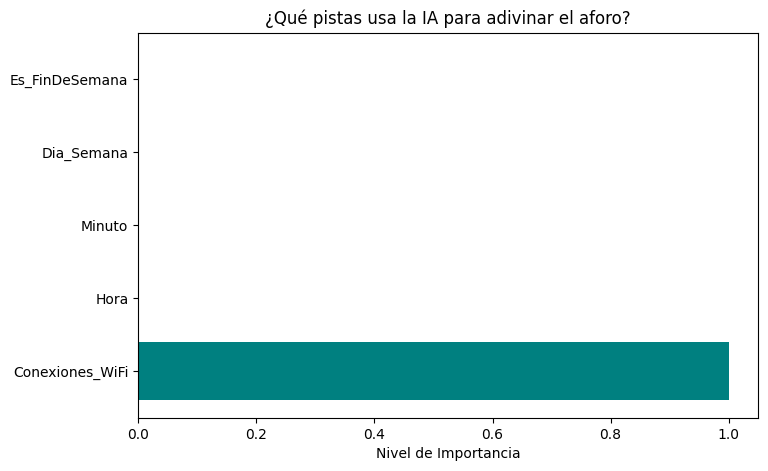

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("1. Separando datos de Entrenamiento (80%) y Test (20%)...")
# Seleccionamos las columnas que la IA puede mirar
features = ['Conexiones_WiFi', 'Hora', 'Minuto', 'Dia_Semana', 'Es_FinDeSemana'] 
X = df_ml[features]

# Esto es lo que tiene que adivinar
y = df_ml['Aforo_Real']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("2. Entrenando el modelo Random Forest... 🚀")
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

print("3. Poniendo a prueba a la IA...")
predicciones = modelo_rf.predict(X_test)

# Evaluando el rendimiento
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print("-" * 30)
print("🎯 RESULTADOS DEL MODELO:")
print(f"Precisión General (R2 Score): {r2:.4f} (El máximo es 1.0)")
print(f"Margen de Error (MAE): +/- {mae:.1f} personas")
print("-" * 30)

# Gráfica: Importancia de las variables (Súper útil para el TFG)
importancias = modelo_rf.feature_importances_
plt.figure(figsize=(8, 5))
plt.barh(features, importancias, color='teal')
plt.title('¿Qué pistas usa la IA para adivinar el aforo?')
plt.xlabel('Nivel de Importancia')
plt.show()

In [ ]:
print("1. Generando predicciones para TODOS los datos...")
# Predecimos en todo el dataset
predicciones_todas = modelo_rf.predict(X)

# Añadimos las predicciones al dataframe
df_ml['Prediccion_Personas'] = predicciones_todas

# Redondeamos a personas (no pueden ser 3.7 personas)
df_ml['Prediccion_Personas'] = df_ml['Prediccion_Personas'].round(0).astype(int)

print("2. Agrupando predicciones por hora...")
df_por_hora = df_ml.groupby('Hora').agg(
    Conexiones_WiFi_Promedio=('Conexiones_WiFi', 'mean'),
    Aforo_Real_Promedio=('Aforo_Real', 'mean'),
    Prediccion_Personas_Promedio=('Prediccion_Personas', 'mean'),
    Registros=('Timestamp', 'count')
).reset_index()

df_por_hora = df_por_hora.round(1)

print("3. Guardando datasets...")
# Exportar dataset detallado (todos los intervalos de 15 minutos)
df_ml.to_csv('../data/dataset_limpio_con_predicciones.csv', index=False)
print(f"   ✓ Dataset detallado guardado: {len(df_ml)} filas")

# Exportar dataset agregado por hora
df_por_hora.to_csv('../data/predicciones_por_hora.csv', index=False)
print(f"   ✓ Dataset por hora guardado: {len(df_por_hora)} filas")

print("\n📊 Preview del dataset por hora:")
print(df_por_hora)

1. Generando predicciones para TODOS los datos...
2. Agrupando predicciones por hora...
3. Guardando datasets...
   ✓ Dataset detallado guardado: 35135 filas
   ✓ Dataset por hora guardado: 24 filas

📊 Preview del dataset por hora:
    Hora  Conexiones_WiFi_Promedio  Aforo_Real_Promedio  \
0      0                      64.0                  0.0   
1      1                      64.0                  0.0   
2      2                      64.0                  0.0   
3      3                      64.0                  0.0   
4      4                      64.0                  0.0   
5      5                      64.0                  0.0   
6      6                      76.4                  7.7   
7      7                     126.6                 38.9   
8      8                     227.8                101.6   
9      9                     532.0                290.3   
10    10                     626.2                348.9   
11    11                     826.2                472.7   
1

: 